In [2]:
from macrodata_tools.data import get_cpi, compute_inflation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid")

# Load Data

In [3]:
cpi = get_cpi()
inflation = compute_inflation(cpi)

inflation.head()

,Inflation
DATE,
2000-01-01,NaN
2000-02-01,NaN
2000-03-01,NaN
2000-04-01,NaN
2000-05-01,NaN


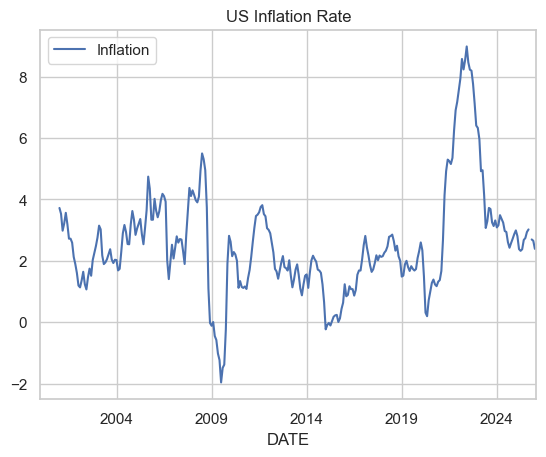

In [4]:
inflation.plot(title="US Inflation Rate")
plt.show()

## Data Cleaning
Remove missing values and inspect structure

In [5]:
inflation = inflation.dropna()

print(inflation.head())
print(inflation.info())

            Inflation
DATE                 
2001-01-01   3.721205
2001-02-01   3.529412
2001-03-01   2.982456
2001-04-01   3.218256
2001-05-01   3.563084
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 301 entries, 2001-01-01 to 2026-02-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Inflation  301 non-null    float64
dtypes: float64(1)
memory usage: 4.7 KB
None


## Descriptive Statistics
Summary statistics of inflation

In [19]:
inflation.describe()

,Inflation
count,300.000000
mean,2.551079
std,1.756040
min,-1.958761
25%,1.608073
50%,2.305234
75%,3.197181
max,8.979361


In [6]:
import numpy as np

mean_inflation = np.mean(inflation["Inflation"])
std_inflation = np.std(inflation["Inflation"])
Max_inflation = np.max(inflation["Inflation"])
Min_inflation = np.min(inflation["Inflation"])

print("Mean inflation:", mean_inflation)
print("Std inflation:", std_inflation)
print("Max inflation:", Max_inflation)
print("Min inflation:", Min_inflation)

Mean inflation: 2.550689844520547
Std inflation: 1.7502096143790442
Max inflation: 8.979361103105798
Min inflation: -1.9587610037622771


# Feature Engineering

In [7]:
# Rolling average
inflation["Rolling_12M"] = inflation["Inflation"].rolling(window=12).mean()

# High inflation flag
inflation["High_Inflation"] = inflation["Inflation"] > 5

# Lag feature for ML
inflation["lag1"] = inflation["Inflation"].shift(1)

inflation = inflation.dropna()
print(inflation.head())

            Inflation  Rolling_12M  High_Inflation      lag1
DATE                                                        
2001-12-01   1.603666     2.822434           False  1.894374
2002-01-01   1.195900     2.611992           False  1.603666
2002-02-01   1.136364     2.412571           False  1.195900
2002-03-01   1.362862     2.277605           False  1.136364
2002-04-01   1.643991     2.146416           False  1.362862


/var/folders/wc/8crrf1850ldfb665mjgpqvww0000gn/T/ipykernel_39810/821974973.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inflation["Rolling_12M"] = inflation["Inflation"].rolling(window=12).mean()
/var/folders/wc/8crrf1850ldfb665mjgpqvww0000gn/T/ipykernel_39810/821974973.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inflation["High_Inflation"] = inflation["Inflation"] > 5
/var/folders/wc/8crrf1850ldfb665mjgpqvww0000gn/T/ipykernel_39810/821974973.py:8: SettingWithCopyWarning: 
A value is trying t

In [22]:
import seaborn as sns

# Distribution of Inflation

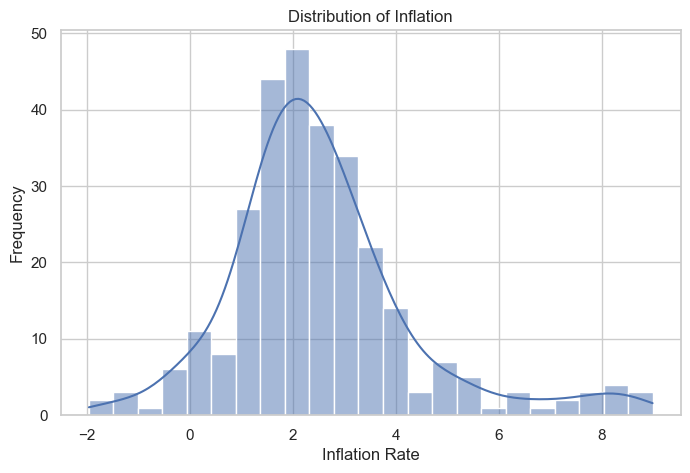

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(inflation["Inflation"], kde=True)
plt.title("Distribution of Inflation")
plt.xlabel("Inflation Rate")
plt.ylabel("Frequency")
plt.show()

# Time Series Visualization

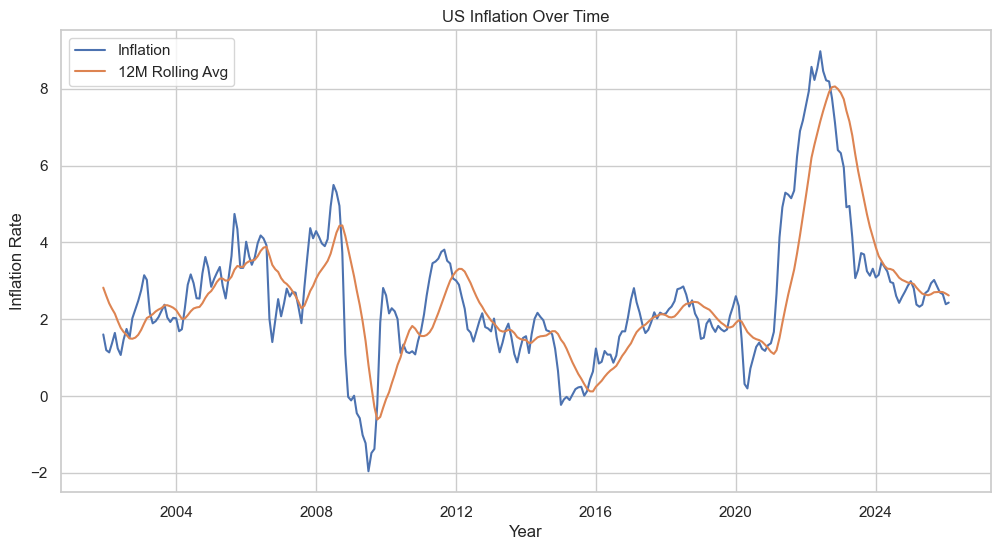

In [9]:
plt.figure(figsize=(12,6))

sns.lineplot(data=inflation, x=inflation.index, y="Inflation", label="Inflation")
sns.lineplot(data=inflation, x=inflation.index, y="Rolling_12M", label="12M Rolling Avg")

plt.title("US Inflation Over Time")
plt.xlabel("Year")
plt.ylabel("Inflation Rate")
plt.legend()
plt.show()

# Recession Shading

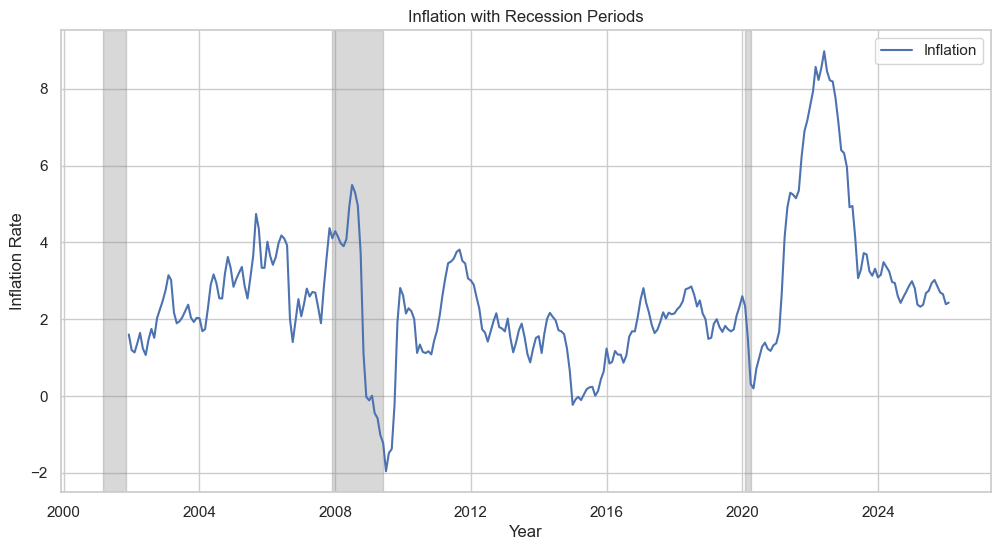

In [10]:
recessions = [
    ("2001-03-01", "2001-11-01"),
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01")
]

plt.figure(figsize=(12,6))

plt.plot(inflation.index, inflation["Inflation"], label="Inflation")

for start, end in recessions:
    plt.axvspan(start, end, color="gray", alpha=0.3)

plt.title("Inflation with Recession Periods")
plt.xlabel("Year")
plt.ylabel("Inflation Rate")
plt.legend()
plt.show()

# High Inflation Periods

In [11]:
print(inflation[inflation["High_Inflation"]].head())

            Inflation  Rolling_12M  High_Inflation      lag1
DATE                                                        
2008-07-01   5.497512     3.971855            True  4.935966
2008-08-01   5.308017     4.256070            True  5.497512
2021-06-01   5.295633     2.287830            True  4.918257
2021-07-01   5.245169     2.641855            True  5.295633
2021-08-01   5.152015     2.964434            True  5.245169


Yearly Inflation Analysis

/var/folders/wc/8crrf1850ldfb665mjgpqvww0000gn/T/ipykernel_39810/3354269209.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_inflation = inflation.resample("Y").mean()


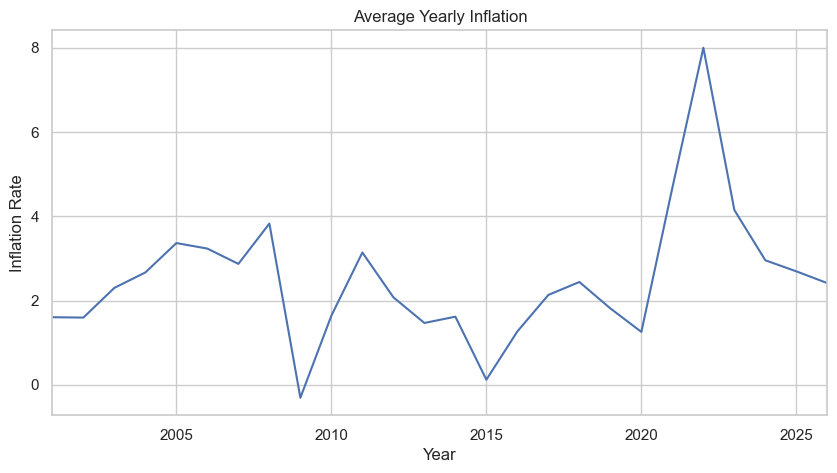

In [12]:
yearly_inflation = inflation.resample("Y").mean()

plt.figure(figsize=(10,5))
yearly_inflation["Inflation"].plot()
plt.title("Average Yearly Inflation")
plt.xlabel("Year")
plt.ylabel("Inflation Rate")
plt.show()

# Machine Learning Model

In [13]:
X = inflation[["lag1"]]
y = inflation["Inflation"]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

print("\nModel Coefficient:", model.coef_)
print("Model Intercept:", model.intercept_)



Model Coefficient: [0.96683041]
Model Intercept: 0.08592311473789405


# Actual Vs Predicted Model

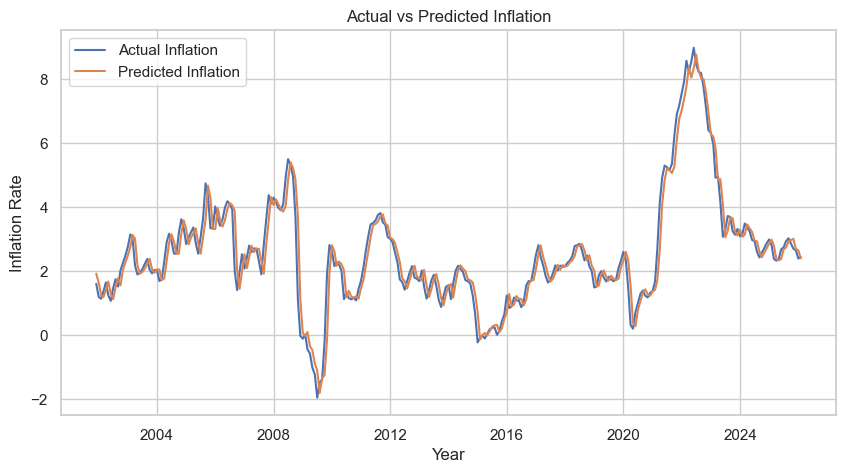

In [14]:
plt.figure(figsize=(10,5))

plt.plot(inflation.index, y, label="Actual Inflation")
plt.plot(inflation.index, predictions, label="Predicted Inflation")

plt.title("Actual vs Predicted Inflation")
plt.xlabel("Year")
plt.ylabel("Inflation Rate")
plt.legend()
plt.show()